# Introduktion til data science med håndskrevne cifre

I dette begynderprojekt skal du arbejde med et lille datasæt med håndskrevne cifre. Datasættet minder om MNIST, men er mindre og nemmere at starte med.

Vi bruger `load_digits()` fra `scikit-learn`. Det indeholder billeder af cifre fra 0 til 9. Hvert billede er kun 8 x 8 pixels.

Du skal lære at:

- indlæse et datasæt
- undersøge data
- visualisere data
- træne en simpel machine learning-model
- validere modellen
- bruge modellen til prediktion
- gentage forsøget med et valgfrit datasæt


## 0. Hvis du mangler biblioteker

Hvis notebooken melder fejl om manglende biblioteker, kan du køre cellen herunder én gang.

Hvis alt allerede virker, kan du springe cellen over.

In [ ]:
# Fjern #-tegnet på næste linje, hvis du mangler bibliotekerne.
# %pip install scikit-learn matplotlib seaborn numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.5.2-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 6.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 9.2 MB/s eta 0:00:00a 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached numpy-2.5.2-cp313-cp313-macosx_14_0_arm64.whl (5.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━

## 1. Importér biblioteker

Et bibliotek er kode, som andre har skrevet, og som vi kan bruge i vores eget program.

I dette projekt bruger vi:

- `sklearn` til datasæt, modeltræning og evaluering
- `matplotlib` til grafer og billeder
- `seaborn` til pænere visualiseringer
- `numpy` til tal og arrays


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets, neighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


## 2. Indlæs datasættet

Et datasæt består typisk af:

- **features**: de data, modellen får som input
- **labels**: de rigtige svar, som modellen skal lære at forudsige

I dette datasæt er hvert billede et håndskrevet ciffer. Modellens opgave er at gætte, hvilket ciffer billedet viser.


In [5]:
digits = datasets.load_digits()

X = digits.data
y = digits.target

print("Datasættets keys:", digits.keys())
print("Antal billeder:", len(X))
print("Form på X:", X.shape)
print("Form på y:", y.shape)
print("Billedstørrelse:", digits.images[0].shape)
print("Mulige labels:", digits.target_names)

Datasættets keys: dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Antal billeder: 1797
Form på X: (1797, 64)
Form på y: (1797,)
Billedstørrelse: (8, 8)
Mulige labels: [0 1 2 3 4 5 6 7 8 9]


### Forklaring

`X` indeholder inputdata. Her er hvert billede lavet om til en liste med 64 tal, fordi billedet er 8 x 8 pixels.

`y` indeholder de rigtige labels. Hvis et billede viser tallet 7, er labelen `7`.

### Opgaver

1. Hvor mange billeder er der i datasættet?
2. Hvor mange features har hvert billede?
3. Hvorfor passer tallet 64 med billedstørrelsen 8 x 8?
4. Hvad tror du værdierne i `X` betyder?


## 3. Se på konkrete billeder

Data science handler ikke kun om at træne modeller. Man skal først forstå sine data.

Her viser vi nogle konkrete billeder fra datasættet.

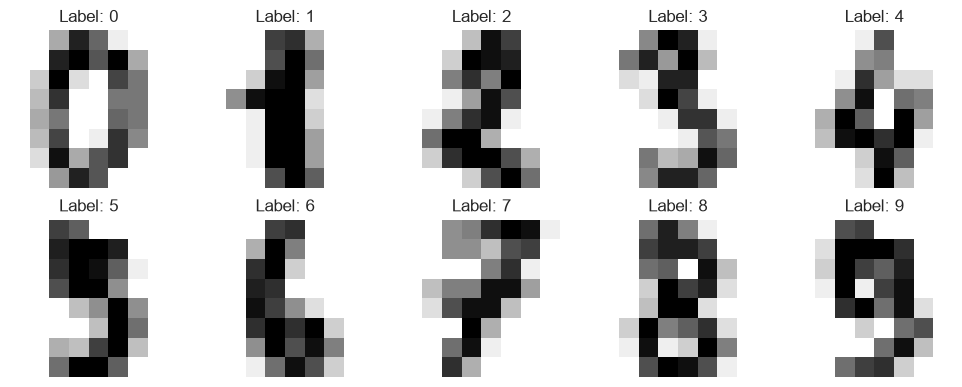

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], y[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Opgaver

1. Ændr koden, så den viser 20 billeder i stedet for 10.
2. Find et billede, som du selv synes er svært at læse.
3. Hvorfor kan håndskrevne cifre være svære for en computer at genkende?


## 4. Undersøg fordelingen af labels

Et datasæt er **balanceret**, hvis der er nogenlunde lige mange eksempler på hver klasse.

Hvis der fx var mange 1-taller, men næsten ingen 8-taller, kunne modellen blive dårligere til at genkende 8-taller.

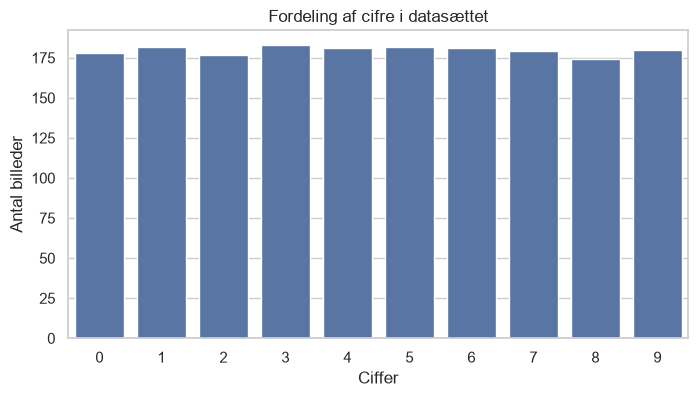

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title("Fordeling af cifre i datasættet")
plt.xlabel("Ciffer")
plt.ylabel("Antal billeder")
plt.show()

### Opgaver

1. Er datasættet balanceret?
2. Hvilket ciffer findes der flest af?
3. Hvilket ciffer findes der færrest af?
4. Hvorfor er det vigtigt at undersøge fordelingen af labels?


## 5. Træningsdata og testdata

Vi deler datasættet i to dele:

- **træningsdata**: bruges til at træne modellen
- **testdata**: bruges til at undersøge, hvor godt modellen virker på data, den ikke har set før

Det er vigtigt, at modellen ikke testes på præcis de samme data, som den er trænet på.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Træningsdata:", X_train.shape)
print("Testdata:", X_test.shape)

### Begreber

`test_size=0.25` betyder, at 25 % af data bruges til test.

`random_state=42` gør, at vi får samme tilfældige opdeling hver gang.

`stratify=y` sørger for, at fordelingen af cifre bliver nogenlunde ens i træningsdata og testdata.

### Opgaver

1. Hvor mange billeder bruges til træning?
2. Hvor mange billeder bruges til test?
3. Hvorfor må vi ikke kun måle modellens kvalitet på træningsdata?


## 6. Træn en simpel model

Vi bruger modellen **K-nearest neighbors**, ofte forkortet **KNN**.

KNN fungerer sådan her:

1. Modellen gemmer træningsdata.
2. Når den får et nyt billede, sammenligner den billedet med billeder, den allerede kender.
3. Den ser på de nærmeste naboer og vælger den klasse, der er mest almindelig blandt dem.

Her starter vi med `n_neighbors=3`, så modellen kigger på de 3 nærmeste naboer.

In [ ]:
model = neighbors.KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

print("Modellen er trænet.")

## 7. Prediktion

At lave en **prediktion** betyder, at modellen giver sit bedste bud på et svar.

Nu lader vi modellen gætte på testdata.

In [ ]:
y_pred = model.predict(X_test)

print("De første 20 rigtige labels:")
print(y_test[:20])

print("\nModellens første 20 gæt:")
print(y_pred[:20])

### Opgaver

1. Sammenlign de første 20 rigtige labels med modellens gæt.
2. Hvor mange af de første 20 ser ud til at være rigtige?
3. Hvorfor er det upraktisk at vurdere modellen manuelt på alle testbilleder?


## 8. Validering af modellen

Når vi **validerer** en model, undersøger vi, hvor godt den virker.

Et simpelt mål er **accuracy**.

Accuracy betyder:

> Andelen af testeksempler, som modellen klassificerer korrekt.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Accuracy i procent: {accuracy * 100:.1f}%")

### Opgaver

1. Hvad blev modellens accuracy?
2. Forklar med egne ord, hvad tallet betyder.
3. Er accuracy alene nok til at forstå modellens fejl?


## 9. Mere detaljeret validering

Accuracy giver ét samlet tal. Men man kan også se på, hvordan modellen klarer sig for hvert enkelt ciffer.

`classification_report` viser flere mål. I dette projekt er det nok, at du fokuserer på kolonnen `precision`, `recall`, `f1-score` og `support` som en første introduktion.


In [ ]:
print(classification_report(y_test, y_pred))

### Opgaver

1. Hvilket ciffer har den højeste f1-score?
2. Hvilket ciffer har den laveste f1-score?
3. Hvad tror du `support` betyder?


## 10. Confusion matrix

En **confusion matrix** viser, hvilke klasser modellen forveksler med hinanden.

Rækkerne viser de rigtige labels. Kolonnerne viser modellens gæt.

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix")
plt.xlabel("Modellens gæt")
plt.ylabel("Rigtigt label")
plt.show()

### Opgaver

1. Hvilke cifre klarer modellen bedst?
2. Hvilke cifre forveksler modellen?
3. Hvor i confusion matrixen ser man de korrekte svar?
4. Hvorfor er en confusion matrix mere informativ end kun accuracy?


## 11. Se fejlklassifikationer

Det er ofte nyttigt at se konkrete fejl. Det kan hjælpe os med at forstå, om fejlene virker rimelige.

In [ ]:
wrong_indices = np.where(y_test != y_pred)[0]

print("Antal fejl:", len(wrong_indices))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, index in zip(axes.ravel(), wrong_indices[:10]):
    image = X_test[index].reshape(8, 8)
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"Rigtig: {y_test[index]} / Gæt: {y_pred[index]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Opgaver

1. Kig på fejlene. Synes du nogle af dem er forståelige?
2. Vælg 3 fejl og forklar, hvorfor modellen måske tager fejl.
3. Er der bestemte cifre, som ofte går galt?


## 12. Prøv at forbedre modellen

Nu skal du ændre modellen og se, om resultatet bliver bedre.

I KNN kan vi ændre `n_neighbors`. Det styrer, hvor mange naboer modellen kigger på, når den skal gætte.

Du skal teste flere værdier og sammenligne accuracy.

In [ ]:
results = []

for k in [1, 3, 5, 7, 9, 11, 15]:
    model = neighbors.KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append((k, accuracy))

results

In [ ]:
k_values = [item[0] for item in results]
accuracies = [item[1] for item in results]

plt.figure(figsize=(8, 4))
sns.lineplot(x=k_values, y=accuracies, marker="o")
plt.title("Accuracy for forskellige værdier af k")
plt.xlabel("k: antal naboer")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"Bedste k: {best_k}")
print(f"Bedste accuracy: {best_accuracy:.3f}")

### Opgaver

1. Hvilken værdi af `k` gav bedst accuracy?
2. Blev modellen altid bedre, når `k` blev større?
3. Hvorfor er det vigtigt at sammenligne flere forsøg?
4. Lav en lille tabel i markdown, hvor du skriver dine resultater ind.


## 13. Kort rapport i notebooken

Skriv dine svar herunder.

### Datasættet

Skriv 5-8 linjer om datasættet.

### Visualisering

Hvilke grafer og billeder lavede du? Hvad viste de?

### Model

Hvilken model brugte du?

### Validering

Hvor god var modellen? Brug konkrete tal.

### Forbedring

Hvad ændrede du? Blev resultatet bedre?


# Ekstra opgave: Gentag med et valgfrit datasæt

Nu skal du gentage arbejdsprocessen med et andet datasæt.

Du skal bruge samme grundstruktur:

1. Indlæs datasættet.
2. Undersøg data.
3. Visualisér data.
4. Del data i træningsdata og testdata.
5. Træn en model.
6. Lav prediktioner.
7. Validér modellen.
8. Forklar resultatet.


## Hvordan finder man et datasæt?

Start med et lille og overskueligt datasæt. Det vigtigste er, at du forstår, hvad rækkerne og kolonnerne betyder.

Gode steder at finde begynderdatasæt:

- `sklearn.datasets`: indbyggede datasæt i Python
- Kaggle: mange datasæt, men kvalitet og sværhedsgrad varierer
- UCI Machine Learning Repository: klassiske datasæt til machine learning
- offentlige data-portaler, fx danske data fra statistikbanker eller kommuner

Til dette projekt anbefales det at starte med et datasæt fra `sklearn.datasets`, fordi det kræver mindst opsætning.

## Forslag 1: Iris-datasættet

Iris-datasættet handler om blomster. Målet er at forudsige blomsterarten ud fra mål som længde og bredde på kronblade og bægerblade.

Det er et godt begynderdatasæt, fordi det er lille og nemt at visualisere.

In [ ]:
iris = datasets.load_iris()

X_iris = iris.data
y_iris = iris.target

print("Features:", iris.feature_names)
print("Klasser:", iris.target_names)
print("Form på X:", X_iris.shape)
print("Form på y:", y_iris.shape)

## Forslag 2: Wine-datasættet

Wine-datasættet handler om kemiske målinger af vin. Målet er at forudsige vintypen.

Det er lidt sværere end Iris, fordi der er flere features.

In [ ]:
wine = datasets.load_wine()

X_wine = wine.data
y_wine = wine.target

print("Features:", wine.feature_names)
print("Klasser:", wine.target_names)
print("Form på X:", X_wine.shape)
print("Form på y:", y_wine.shape)

## Din egen undersøgelse

Vælg enten Iris, Wine eller et andet datasæt.

### Krav

- Du skal beskrive datasættet.
- Du skal lave mindst 2 visualiseringer.
- Du skal træne mindst 1 model.
- Du skal validere modellen med accuracy eller en anden passende metode.
- Du skal forklare mindst 3 centrale begreber fra projektet.
- Du skal sammenligne dit nye datasæt med digits-datasættet.

### Spørgsmål

1. Hvad forsøger modellen at forudsige?
2. Hvad er features?
3. Hvad er labels?
4. Hvilke visualiseringer hjælper dig med at forstå datasættet?
5. Hvor godt klarer modellen sig?
6. Hvad ville du prøve at ændre, hvis modellen skulle forbedres?


# Aflevering

Aflever denne notebook med alle kodeceller kørt og alle refleksionsspørgsmål besvaret.

Din notebook skal vise, at du kan:

- bruge Python til at undersøge data
- lave relevante visualiseringer
- træne en simpel model
- teste og validere modellen
- forklare centrale data science-begreber
- gentage metoden på et nyt datasæt
